# Notebook 4: Hồi quy Nâng cao

## Đọc dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time
from utils import (
    load_bike_data,
    evaluate_model,
    plot_sklearn_learning_curve_wrapper,
    plot_learning_curve_data_size,
)

(
    train_df,
    features_to_drop,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    X_test_scaled,
    y_test,
    X_train_b,
    X_val_b,
    X_test_b,
) = load_bike_data()

## 4. Mô hình Nâng cao

In [2]:
from sklearn.linear_model import (
    BayesianRidge,
    HuberRegressor,
    LinearRegression,
    RidgeCV,
    Ridge,
)
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
import time

### 4.1 Bayesian Regression & Evidence Maximization

Bayesian Ridge (Evidence Maximization):
 - Optimal Alpha (noise precision): 0.0001
 - Optimal Lambda (weight precision): 0.0001
 - LML Score (Maximized Evidence): -75569.0191
 - Training Time: 0.0104 sec
 - Test MSE: 33663.6854

Ridge CV:
 - Optimal Regularization Alpha: 85.3168
 - Training Time: 0.4220 sec
 - Test MSE: 34213.5101
[Bayesian Ridge] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17006.45 ± 9629.60
  - CV_RMSE (Mean ± Std): 125.21 ± 36.46
  - CV_MAE (Mean ± Std): 98.19 ± 31.31
  - CV_R2 (Mean ± Std): 0.2329 ± 0.2025
  - Val MSE: 34907.8869
  - Val RMSE: 186.8365
  - Val MAE: 154.8233
  - Val R2: 0.2715
  - Test MSE: 33663.6854
  - Test RMSE: 183.4767
  - Test MAE: 142.3818
  - Test R2: 0.3075


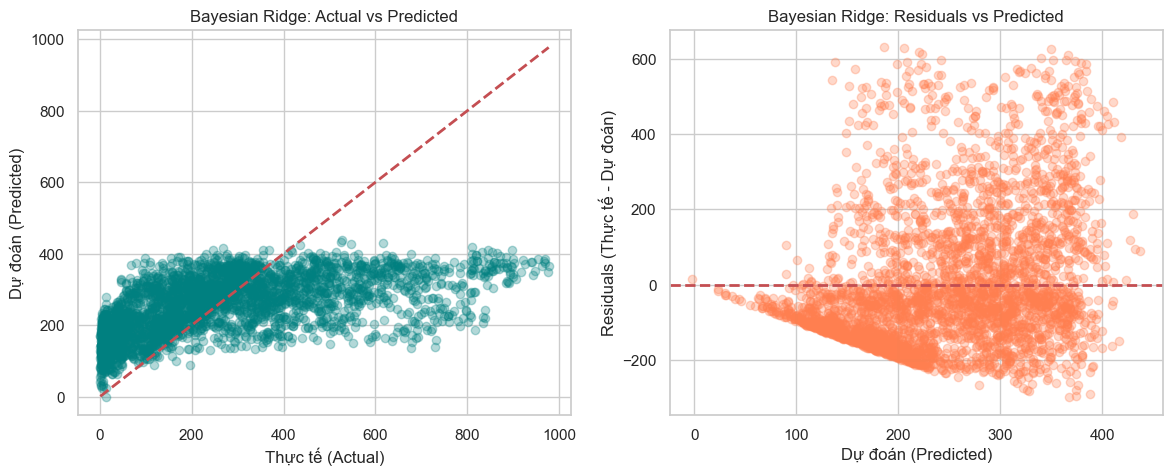

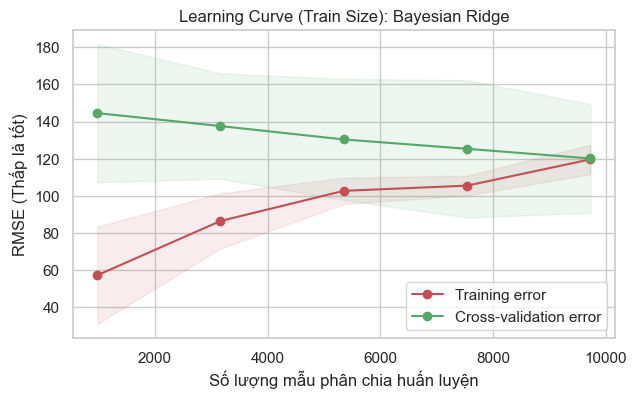

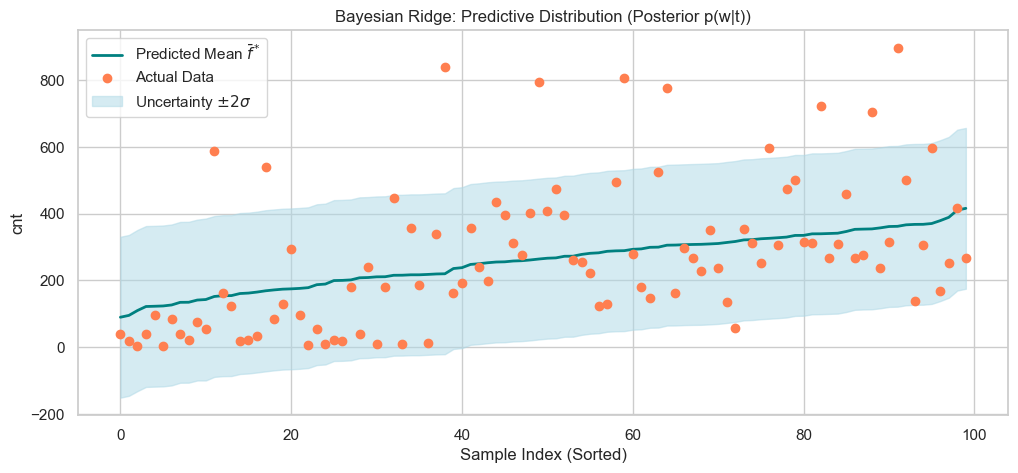

In [3]:

# Chạy Bayesian Ridge
start_bayes = time.time()
model_bayes = BayesianRidge(max_iter=300, compute_score=True)
model_bayes.fit(X_train_scaled, y_train)
time_bayes = time.time() - start_bayes

# Chạy RidgeCV để so sánh thời gian và MSE
start_ridgecv = time.time()
ridge_cv_model = RidgeCV(alphas=np.logspace(-2, 4, 30), cv=10)
ridge_cv_model.fit(X_train_scaled, y_train)
time_ridgecv = time.time() - start_ridgecv

print(f"Bayesian Ridge (Evidence Maximization):")
print(f" - Optimal Alpha (noise precision): {model_bayes.alpha_:.4f}")
print(f" - Optimal Lambda (weight precision): {model_bayes.lambda_:.4f}")
print(f" - LML Score (Maximized Evidence): {model_bayes.scores_[-1]:.4f}")
print(f" - Training Time: {time_bayes:.4f} sec")
print(
    f" - Test MSE: {mean_squared_error(y_test, model_bayes.predict(X_test_scaled)):.4f}\n"
)

print(f"Ridge CV:")
print(f" - Optimal Regularization Alpha: {ridge_cv_model.alpha_:.4f}")
print(f" - Training Time: {time_ridgecv:.4f} sec")
print(
    f" - Test MSE: {mean_squared_error(y_test, ridge_cv_model.predict(X_test_scaled)):.4f}"
)


def fit_pred_bayes(X_tr, y_tr, X_val):
    return model_bayes.predict(X_val), model_bayes


_ = evaluate_model(
    "Bayesian Ridge",
    fit_pred_bayes,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_val_scaled,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    BayesianRidge(max_iter=300), "Bayesian Ridge", X_train_scaled, y_train
)

# Plot Dải tự tin test
y_pred_bayes, y_std_bayes = model_bayes.predict(X_test_scaled, return_std=True)
np.random.seed(42)
indices = np.random.choice(len(y_test), 100, replace=False)
sorted_idx = np.argsort(y_pred_bayes[indices])
idx_to_plot = indices[sorted_idx]

plt.figure(figsize=(12, 5))
plt.plot(
    y_pred_bayes[idx_to_plot], color="teal", label="Predicted Mean $\\bar{f}^*$", lw=2
)
plt.scatter(
    range(100), y_test[idx_to_plot], color="coral", label="Actual Data", zorder=3
)
plt.fill_between(
    range(100),
    y_pred_bayes[idx_to_plot] - 2 * y_std_bayes[idx_to_plot],
    y_pred_bayes[idx_to_plot] + 2 * y_std_bayes[idx_to_plot],
    color="lightblue",
    alpha=0.5,
    label="Uncertainty $\\pm 2\\sigma$",
)
plt.title("Bayesian Ridge: Predictive Distribution (Posterior p(w|t))")
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("cnt")
plt.legend()
plt.show()

### 4.2 Kernel Ridge Regression (KRR)
Cài đặt với 2 Kernel: RBF và Polynomial và chọn tham số bằng Cross-Validation.

Optimal KRR Parameters: {'alpha': np.float64(0.01), 'degree': 2, 'gamma': np.float64(0.1), 'kernel': 'rbf'}
[Kernel Ridge (CV)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 2070.02 ± 3533.15
  - CV_RMSE (Mean ± Std): 37.07 ± 26.37
  - CV_MAE (Mean ± Std): 24.37 ± 17.56
  - CV_R2 (Mean ± Std): 0.9339 ± 0.0677
  - Val MSE: 11171.9633
  - Val RMSE: 105.6975
  - Val MAE: 69.5635
  - Val R2: 0.7668
  - Test MSE: 19765.9119
  - Test RMSE: 140.5913
  - Test MAE: 99.0981
  - Test R2: 0.5934


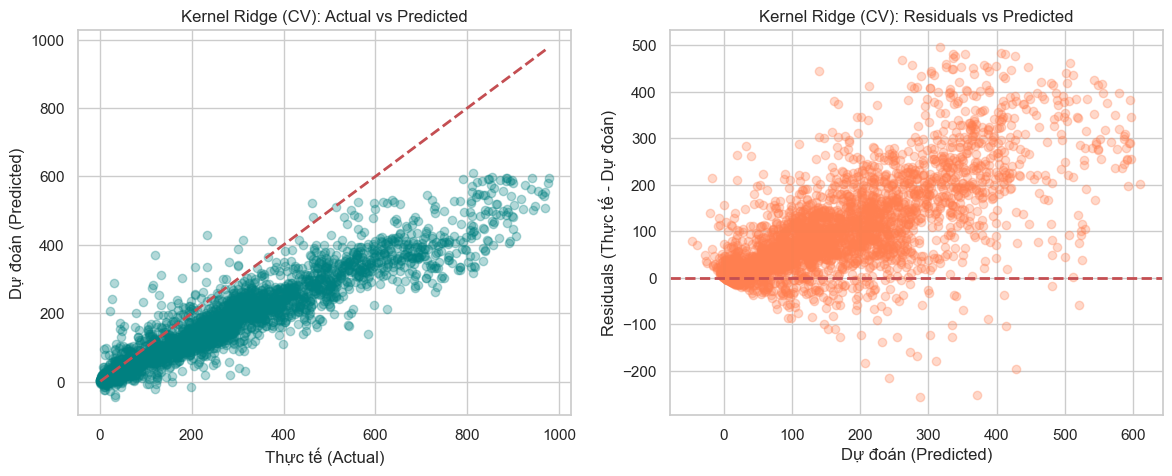

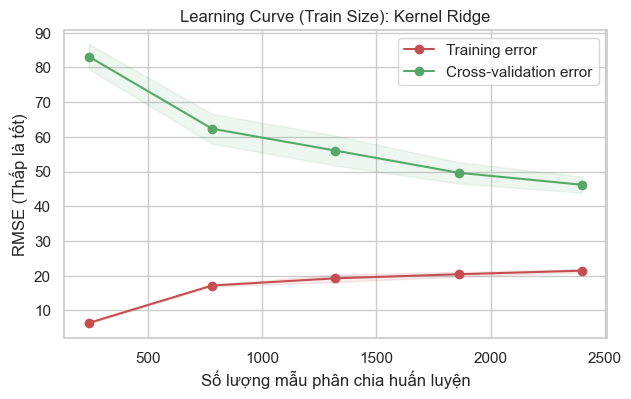

In [4]:

krr_params = {
    "kernel": ["rbf", "polynomial"],
    "alpha": np.logspace(-2, 2, 3),  # Regularization
    "gamma": np.logspace(-2, 0, 3),  # Bandwidth cho RBF / Poly
    "degree": [2, 3],  # Chỉ dùng nếu kernel là polynomial
}

# Subsample để GridSearch chạy nhanh hơn do KRR scale O(N^3)
X_train_sub, y_train_sub = resample(
    X_train_scaled, y_train, n_samples=3000, random_state=42
)

krr_grid = GridSearchCV(
    KernelRidge(), krr_params, cv=3, scoring="neg_mean_squared_error", n_jobs=-1
)
krr_grid.fit(X_train_sub, y_train_sub)

print(f"Optimal KRR Parameters: {krr_grid.best_params_}")

model_krr = krr_grid.best_estimator_
model_krr.fit(X_train_scaled, y_train)


def fit_pred_kr(X_tr, y_tr, X_val):
    return model_krr.predict(X_val), model_krr


_ = evaluate_model(
    "Kernel Ridge (CV)",
    fit_pred_kr,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_val_scaled,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    KernelRidge(**krr_grid.best_params_), "Kernel Ridge", X_train_sub, y_train_sub
)

### 4.3 Gaussian Process Regression (GPR)
Tối ưu Log-Marginal-Likelihood bằng gradient ascent L-BFGS-B (mặc định Sklearn)

Learned Kernel Parameters (Gradient Ascent): 31.6**2 * RBF(length_scale=0.209)
Maximized Log-Marginal-Likelihood: -38631.3580
[Gaussian Process] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 50035.90 ± 34396.05
  - CV_RMSE (Mean ± Std): 210.05 ± 76.90
  - CV_MAE (Mean ± Std): 150.38 ± 60.84
  - CV_R2 (Mean ± Std): -0.9905 ± 0.2535
  - Val MSE: 124093.8697
  - Val RMSE: 352.2696
  - Val MAE: 275.9500
  - Val R2: -1.5898
  - Test MSE: 110492.2608
  - Test RMSE: 332.4038
  - Test MAE: 248.7544
  - Test R2: -1.2729


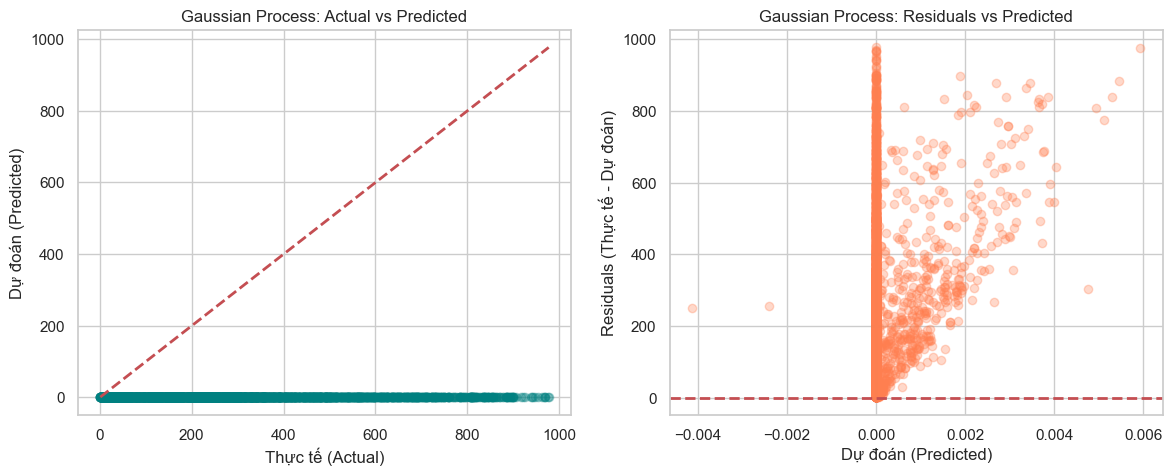

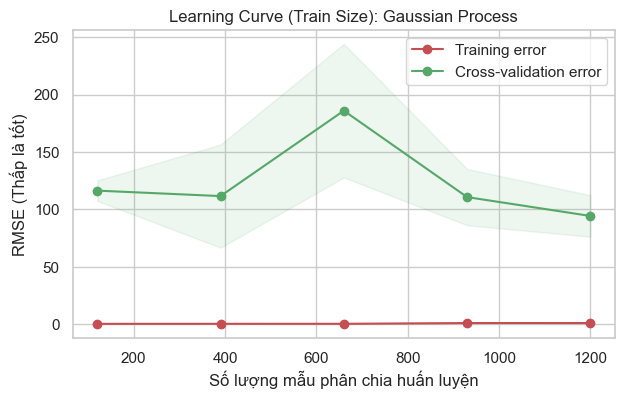

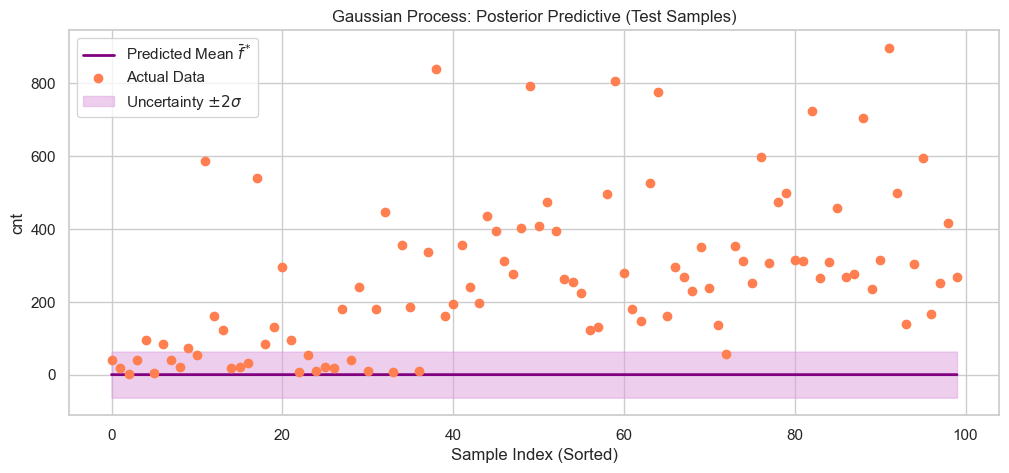

In [5]:
# Sử dụng ConstantKernel * RBF để học scale chiều cao và chiều ngang
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# GPR chạy rất lâu với N lớn, phải subsample
X_gpr_tr, y_gpr_tr = resample(X_train_scaled, y_train, n_samples=1500, random_state=42)

gpr = GaussianProcessRegressor(
    kernel=kernel, alpha=0.5, n_restarts_optimizer=2, random_state=42
)
gpr.fit(X_gpr_tr, y_gpr_tr)

print(f"Learned Kernel Parameters (Gradient Ascent): {gpr.kernel_}")
print(f"Maximized Log-Marginal-Likelihood: {gpr.log_marginal_likelihood_value_:.4f}")


def fit_pred_gpr(X_tr, y_tr, X_val):
    return gpr.predict(X_val), gpr


_ = evaluate_model(
    "Gaussian Process",
    fit_pred_gpr,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_val_scaled,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    GaussianProcessRegressor(kernel=kernel, alpha=0.5, random_state=42),
    "Gaussian Process",
    X_gpr_tr,
    y_gpr_tr,
)

y_pred_gp, y_std_gp = gpr.predict(X_test_scaled, return_std=True)

plt.figure(figsize=(12, 5))
plt.plot(
    y_pred_gp[idx_to_plot], color="purple", label="Predicted Mean $\\bar{f}^*$", lw=2
)
plt.scatter(
    range(100), y_test[idx_to_plot], color="coral", label="Actual Data", zorder=3
)
plt.fill_between(
    range(100),
    y_pred_gp[idx_to_plot] - 2 * y_std_gp[idx_to_plot],
    y_pred_gp[idx_to_plot] + 2 * y_std_gp[idx_to_plot],
    color="plum",
    alpha=0.5,
    label="Uncertainty $\\pm 2\\sigma$",
)
plt.title("Gaussian Process: Posterior Predictive (Test Samples)")
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("cnt")
plt.legend()
plt.show()

### 4.4 Robust Regression (IRLS với Huber Loss)
So sánh tính Robust của Huber và OLS trên dữ liệu có Outliers

With Outliers - OLS MSE: 148666.5642
With Outliers - Huber MSE: 36761.6950


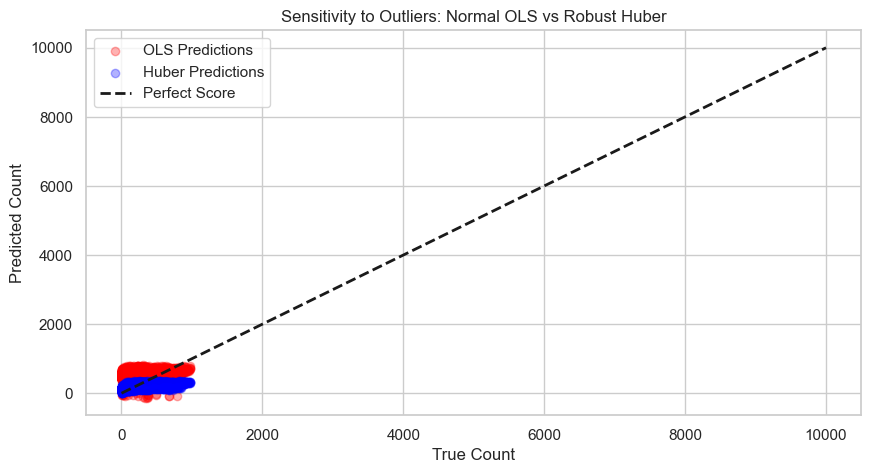

[Huber Robust] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 18433.44 ± 10257.68
  - CV_RMSE (Mean ± Std): 130.65 ± 36.95
  - CV_MAE (Mean ± Std): 95.68 ± 27.03
  - CV_R2 (Mean ± Std): 0.1501 ± 0.2743
  - Val MSE: 35123.5337
  - Val RMSE: 187.4127
  - Val MAE: 139.6328
  - Val R2: 0.2670
  - Test MSE: 37416.9335
  - Test RMSE: 193.4346
  - Test MAE: 134.5736
  - Test R2: 0.2303


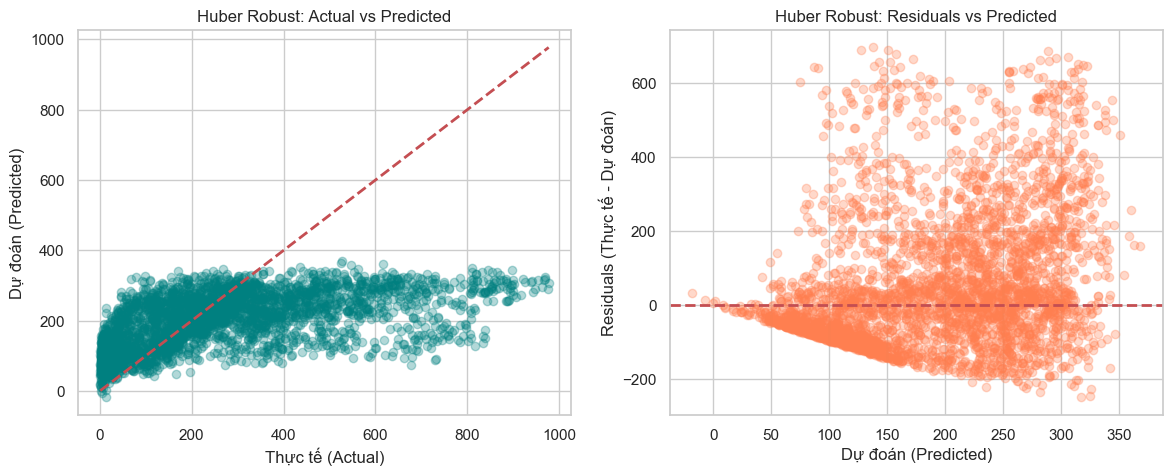

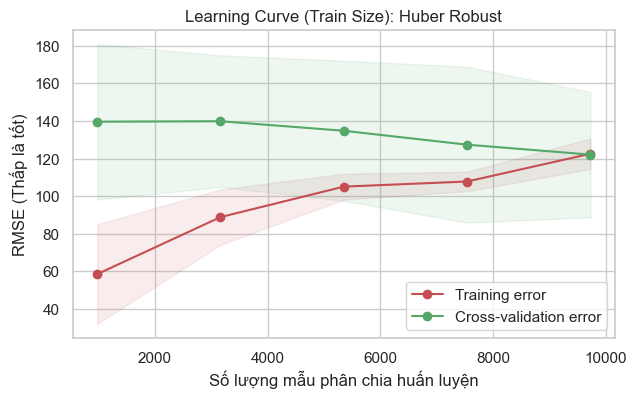

In [6]:
# Bơm outlier (Nhiễu cực lớn)
np.random.seed(42)
outlier_idx = np.random.choice(len(X_train_scaled), 200, replace=False)
y_train_outlier = y_train.copy().astype(float)
y_train_outlier[outlier_idx] = 15000  # Nhiễu lớn vô lý

ols_outlier = LinearRegression()
ols_outlier.fit(X_train_scaled, y_train_outlier)
ols_outlier_pred = ols_outlier.predict(X_test_scaled)
ols_mse = mean_squared_error(y_test, ols_outlier_pred)

# Huber Regressor (thực thi IRLS bên dưới)
huber_outlier = HuberRegressor(epsilon=1.35, max_iter=2000)
huber_outlier.fit(X_train_scaled, y_train_outlier)
huber_outlier_pred = huber_outlier.predict(X_test_scaled)
huber_mse = mean_squared_error(y_test, huber_outlier_pred)

print(f"With Outliers - OLS MSE: {ols_mse:.4f}")
print(f"With Outliers - Huber MSE: {huber_mse:.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(y_test, ols_outlier_pred, alpha=0.3, color="red", label="OLS Predictions")
plt.scatter(
    y_test, huber_outlier_pred, alpha=0.3, color="blue", label="Huber Predictions"
)
plt.plot([0, 10000], [0, 10000], "k--", lw=2, label="Perfect Score")
plt.title("Sensitivity to Outliers: Normal OLS vs Robust Huber")
plt.xlabel("True Count")
plt.ylabel("Predicted Count")
plt.legend()
plt.show()


def fit_pred_huber(X_tr, y_tr, X_val):
    model = HuberRegressor(epsilon=1.35, max_iter=2000)
    model.fit(X_tr, y_tr)
    return model.predict(X_val), model


_ = evaluate_model(
    "Huber Robust",
    fit_pred_huber,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    X_val_scaled,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    HuberRegressor(epsilon=1.35, max_iter=2000), "Huber Robust", X_train_scaled, y_train
)

### 4.5 Phân tích Bias-Variance Thực Nghiệm (Bootstrap)
Bootstrap 200 lần để quan sát Error = Bias^2 + Variance

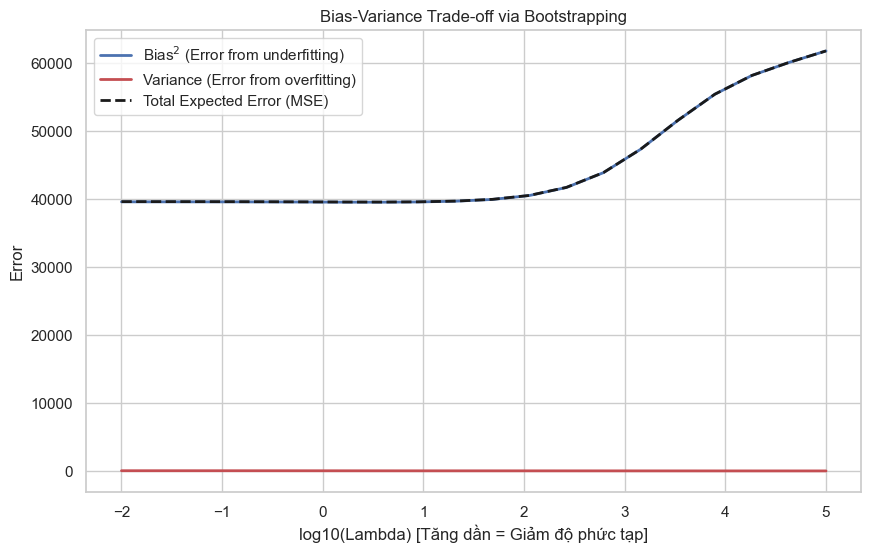

In [7]:
n_bootstraps = 200
lambda_range = np.logspace(-2, 5, 20)
test_size = min(1000, len(y_test))
X_test_sub = X_test_scaled[:test_size]
y_test_sub = y_test[:test_size]

biases_sq = []
variances = []
mses = []

for lam in lambda_range:
    all_preds = np.zeros((n_bootstraps, test_size))
    for b in range(n_bootstraps):
        X_b, y_b = resample(X_train_scaled, y_train, random_state=b)
        model = Ridge(alpha=lam)
        model.fit(X_b, y_b)
        all_preds[b, :] = model.predict(X_test_sub)

    expected_pred = np.mean(all_preds, axis=0)
    bias_sq = np.mean((expected_pred - y_test_sub) ** 2)
    variance = np.mean(np.var(all_preds, axis=0))
    mse = np.mean((all_preds - y_test_sub) ** 2)

    biases_sq.append(bias_sq)
    variances.append(variance)
    mses.append(mse)

plt.figure(figsize=(10, 6))
plt.plot(
    np.log10(lambda_range),
    biases_sq,
    "b-",
    label="Bias$^2$ (Error from underfitting)",
    lw=2,
)
plt.plot(
    np.log10(lambda_range),
    variances,
    "r-",
    label="Variance (Error from overfitting)",
    lw=2,
)
plt.plot(np.log10(lambda_range), mses, "k--", label="Total Expected Error (MSE)", lw=2)
plt.xlabel("log10(Lambda) [Tăng dần = Giảm độ phức tạp]")
plt.ylabel("Error")
plt.title("Bias-Variance Trade-off via Bootstrapping")
plt.legend()
plt.grid(True)
plt.show()